## 프로젝트: 한영 번역기 (Seq2seq with Attention)

한영 병렬 코퍼스를 활용하여 한국어를 영어로 번역하는 **Attention 기반 Seq2seq 모델**을 설계하고 학습한다.


## 0. 환경 설정 및 라이브러리 점검

In [35]:
import os
import re
import urllib.request
import tarfile
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pecab import PeCab # r.md specifies Mecab, but PeCab is available in this environment

print(torch.__version__)

2.10.0+cu128


## 1. 데이터 확보 (Step 1), 데이터 정제 (Step 2)

데이터의 품질을 높이기 위해 중복 제거 및 전처리 과정을 거칩니다.

In [36]:
class DataHandler:
    def __init__(self, ko_path, en_path):
        self.ko_path = ko_path
        self.en_path = en_path
        self.pecab = PeCab()
        self.data_url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/master/"
                         "korean-english-news-v1/korean-english-park.train.tar.gz")
        self.data_filename = "korean-english-park.train.tar.gz"

    def download_data(self):
        if not os.path.exists(self.data_filename):
            print(f"Downloading {self.data_filename}...")
            urllib.request.urlretrieve(self.data_url, self.data_filename)

    def extract_data(self):
        print(f"Extracting {self.data_filename}...")
        with tarfile.open(self.data_filename, "r:gz") as tar:
            tar.extractall()

    def load_raw_data(self):
        if not os.path.exists(self.ko_path) or not os.path.exists(self.en_path):
            self.download_data()
            self.extract_data()

        with open(self.ko_path, "r", encoding="utf-8") as f: ko_corpus = f.read().splitlines()
        with open(self.en_path, "r", encoding="utf-8") as f: en_corpus = f.read().splitlines()
            
        cleaned_corpus = list(set(zip(ko_corpus, en_corpus)))
        return cleaned_corpus

    def preprocess_sentence(self, sentence):
        sentence = sentence.lower().strip()
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r'[" "]+', " ", sentence)
        sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9?.!,]+", " ", sentence)
        return sentence.strip()

    def tokenize_manual(self, corpus, max_len=40, cache_file="tokens_manual.pkl"):
        if os.path.exists(cache_file):
            print(f"Loading cached tokens from {cache_file}...")
            with open(cache_file, "rb") as f:
                return pickle.load(f)

        kor_corpus = []
        eng_corpus = []
        for ko, en in tqdm(corpus, desc="Tokenizing"):
            ko_pre = self.preprocess_sentence(ko)
            en_pre = self.preprocess_sentence(en)
            
            # KR: PeCab, EN: split + start/end
            ko_tokens = self.pecab.morphs(ko_pre)
            en_tokens = ["<start>"] + en_pre.split() + ["<end>"]
            
            if len(ko_tokens) <= max_len and len(en_tokens) <= max_len:
                kor_corpus.append(ko_tokens)
                eng_corpus.append(en_tokens)

        print(f"Saving tokenized results to {cache_file}...")
        with open(cache_file, "wb") as f:
            pickle.dump((kor_corpus, eng_corpus), f)

        return kor_corpus, eng_corpus

    def sequences_to_tensor(self, sentences, tokenizer, max_len=40):
        tensor = []
        for tokens in sentences:
            ids = tokenizer.encode(tokens)
            if len(ids) < max_len:
                ids += [0] * (max_len - len(ids))
            else:
                ids = ids[:max_len]
            tensor.append(ids)
        return torch.tensor(tensor)

### 데이터 로드 및 중복 제거

In [37]:
import pandas as pd
from collections import Counter

handler = DataHandler(
    ko_path="korean-english-park.train.ko",
    en_path="korean-english-park.train.en"
)
raw_data = handler.load_raw_data()
df = pd.DataFrame(raw_data, columns=["ko", "en"])

print(f"전체 데이터 개수: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"중복 제거 후 데이터 개수: {len(df)}")
df.head()

전체 데이터 개수: 78968
중복 제거 후 데이터 개수: 78968


,ko,en
0,상반기 신용 카드 지출 40% 감소 2005.08,Credit-card spending tumbles 40% in first half.
1,해군 대변인은 납치된 모터보트가 북부에 있는 항구인 바히아 솔라노에서 승객 19명을...,The boat had set sail with 19 passengers from ...
2,"고혈압이 더욱 이른 시기에 진단되어 치료되고 있기 때문에, 그리고 또한, 무엇보다도...",High blood pressure is being diagnosed and tre...
3,영국의 통신사는 “시추선에 타고 있던 한 여성이 장치의 작동이 위험하다고 주장해 경...,The British Press Association said the inciden...
4,그들은 관공서 일자리 고용에서부터 주지사의 친구나 기부자들의 행동에 이르기까지 일리...,They've been looking at everything from the Il...


### 데이터 길이 분석 (EDA)

한국어 문장 길이 통계:
count    78968.000000
mean        63.927477
std         27.627125
min          1.000000
25%         44.000000
50%         62.000000
75%         81.000000
max        377.000000
Name: ko_len, dtype: float64

영어 문장 길이 통계:
count    78968.000000
mean       133.883155
std         60.891960
min          1.000000
25%         89.000000
50%        128.000000
75%        173.000000
max        605.000000
Name: en_len, dtype: float64


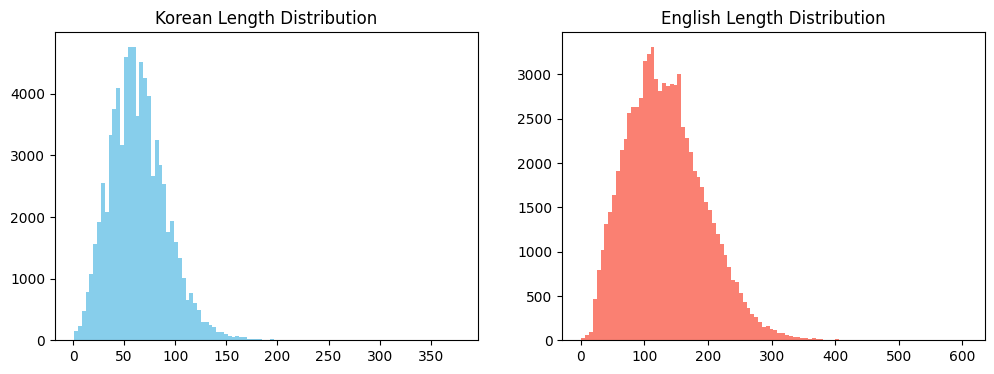

In [38]:
df["ko_len"] = df["ko"].apply(len)
df["en_len"] = df["en"].apply(len)

print("한국어 문장 길이 통계:")
print(df["ko_len"].describe())
print("\n영어 문장 길이 통계:")
print(df["en_len"].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df["ko_len"], bins=100, color='skyblue')
plt.title("Korean Length Distribution")
plt.subplot(1, 2, 2)
plt.hist(df["en_len"], bins=100, color='salmon')
plt.title("English Length Distribution")
plt.show()

### 노이즈 체크 및 이상치 확인

In [39]:
def check_noise(df):
    if len(df) == 0:
        print("데이터가 비어 있습니다.")
        return

    # NaN 결측치 처리 및 문자열 타입 보장
    df_clean = df.copy()
    df_clean["ko"] = df_clean["ko"].fillna("").astype(str)
    
    # 한글 코퍼스 내 영어 포함 데이터 확인
    # apply + re.search 방식을 사용하여 호환성 보장
    en_in_ko = df_clean[df_clean["ko"].apply(lambda x: bool(re.search(r'[a-zA-Z]', x)))]
    print(f"영어 포함 한국어 문장: {len(en_in_ko)} ({len(en_in_ko)/len(df_clean)*100:.2f}%)")
    
    # 한자 포함 데이터 확인 (Unicode [\u4e00-\u9fff])
    hanja_regex = r'[\u4e00-\u9fff]'
    hanja_in_ko = df_clean[df_clean["ko"].apply(lambda x: bool(re.search(hanja_regex, x)))]
    print(f"한자 포함 한국어 문장: {len(hanja_in_ko)} ({len(hanja_in_ko)/len(df_clean)*100:.2f}%)")
    
    # 특수문자 확인
    spec_chars = df_clean[df_clean["ko"].apply(lambda x: bool(re.search(r'[^ㄱ-ㅎㅏ-ㅣ가-힣0-9a-zA-Z\s?.!,]', x)))]
    print(f"특수문자 포함 한국어 문장: {len(spec_chars)} ({len(spec_chars)/len(df_clean)*100:.2f}%)")

check_noise(df)

영어 포함 한국어 문장: 15570 (19.72%)
한자 포함 한국어 문장: 667 (0.84%)
특수문자 포함 한국어 문장: 28820 (36.50%)


## 3. 데이터 토큰화 (Step 3)

In [40]:
class Tokenizer:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.word2idx = {"<pad>": 0, "<unk>": 1, "<start>": 2, "<end>": 3}
        self.idx2word = {0: "<pad>", 1: "<unk>", 2: "<start>", 3: "<end>"}
        self.counts = {}

    def build_vocab(self, corpus):
        for sentence in corpus:
            for word in sentence:
                self.counts[word] = self.counts.get(word, 0) + 1
        sorted_words = sorted(self.counts.items(), key=lambda x: x[1], reverse=True)
        for word, _ in sorted_words[:self.vocab_size - 4]:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, sentence):
        return [self.word2idx.get(word, 1) for word in sentence]

    def decode(self, ids):
        return [self.idx2word.get(idx, "<unk>") for idx in ids]

class TranslationDataset(Dataset):
    def __init__(self, src_tensor, trg_tensor):
        self.src = src_tensor
        self.trg = trg_tensor
    def __len__(self): return len(self.src)
    def __getitem__(self, idx): return self.src[idx], self.trg[idx]

## 4. 모델 설계 (Step 4)

In [41]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention):
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, vocab_size)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        a = self.attention(hidden[-1], encoder_outputs).unsqueeze(1)
        enc_out = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, enc_out).permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output = output.squeeze(0)
        context = context.squeeze(0)
        cat = torch.cat((output, context), dim=1)
        prediction = self.fc_out(cat)
        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40):
        batch_size = src.shape[1]
        outputs = []
        attentions = []
        enc_output, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, a = self.decoder(input, hidden, enc_output)
                outputs.append(output.unsqueeze(0))
        else:
            input = torch.full((batch_size,), 2, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, a = self.decoder(input, hidden, enc_output)
                outputs.append(output.unsqueeze(0))
                attentions.append(a.unsqueeze(0))
                input = output.argmax(1)
                finished |= (input == 3)
                if finished.all(): break

        return torch.cat(outputs, dim=0), (torch.cat(attentions, dim=0) if attentions else None)

## 5. 모델 훈련 및 결과 제출 (Step 5)

In [42]:
class NMTManager:
    def __init__(self, model, optimizer, criterion, device, data_handler):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.data_handler = data_handler

    def train(self, loader, epochs, kor_tok, eng_tok):
        print("\nStarting Training...")
        for epoch in range(epochs):
            self.model.train()
            epoch_loss = 0
            progress = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
            for src, trg in progress:
                src, trg = src.permute(1, 0).to(self.device), trg.permute(1, 0).to(self.device)
                self.optimizer.zero_grad()
                output, _ = self.model(src, trg[:-1, :])
                output = output.view(-1, self.model.decoder.fc_out.out_features)
                trg_label = trg[1:, :].reshape(-1)
                loss = self.criterion(output, trg_label)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                epoch_loss += loss.item()
                progress.set_postfix(loss=loss.item())
            
            print(f"Epoch {epoch+1} Loss: {epoch_loss/len(loader):.4f}")
            self.evaluate_sample_cases(kor_tok, eng_tok)

    def translate(self, sentence, kor_tok, eng_tok, max_len=40, return_attention=False):
        self.model.eval()
        pre = self.data_handler.preprocess_sentence(sentence)
        tokens = self.data_handler.pecab.morphs(pre)
        ids = kor_tok.encode(tokens)
        src_tensor = torch.tensor(ids).unsqueeze(1).to(self.device)
        
        with torch.no_grad():
            output, attentions = self.model(src_tensor, max_len=max_len)
        
        pred_ids = output.argmax(2).squeeze(1).cpu().tolist()
        pred_tokens = eng_tok.decode(pred_ids)
        if "<end>" in pred_tokens:
            pred_tokens = pred_tokens[:pred_tokens.index("<end>")]
        
        if return_attention:
            return " ".join(pred_tokens), tokens, pred_tokens, attentions.squeeze(1).cpu().numpy()
        return " ".join(pred_tokens)

    def evaluate_sample_cases(self, kor_tok, eng_tok):
        test_cases = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]
        for i, tc in enumerate(test_cases):
            print(f"K{i+1}: {self.translate(tc, kor_tok, eng_tok)}")

    def visualize_attention(self, sentence, kor_tok, eng_tok):
        translation, src_tokens, trg_tokens, attention = self.translate(sentence, kor_tok, eng_tok, return_attention=True)
        
        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(1,1,1)
        cax = ax.matshow(attention, cmap='bone')
        
        ax.tick_params(labelsize=15)
        ax.set_xticklabels([''] + src_tokens, rotation=45)
        ax.set_yticklabels([''] + trg_tokens)
        
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
        
        plt.show()

## 6. 실험 실행

In [44]:
def run_experiment(config, test_cases):
    handler = DataHandler(config["ko_path"], config["en_path"])
    raw_data = handler.load_raw_data()
    kor_corpus, eng_corpus = handler.tokenize_manual(raw_data)

    kor_tok = Tokenizer(config["vocab_size"])
    eng_tok = Tokenizer(config["vocab_size"])
    kor_tok.build_vocab(kor_corpus)
    eng_tok.build_vocab(eng_corpus)

    kor_tensor = handler.sequences_to_tensor(kor_corpus, kor_tok)
    eng_tensor = handler.sequences_to_tensor(eng_corpus, eng_tok)

    loader = DataLoader(TranslationDataset(kor_tensor, eng_tensor), batch_size=config["batch_size"], shuffle=True)

    encoder = Encoder(config["vocab_size"], config["emb_dim"], config["hid_dim"]).to(config["device"])
    attention = BahdanauAttention(config["hid_dim"]).to(config["device"])
    decoder = Decoder(config["vocab_size"], config["emb_dim"], config["hid_dim"], attention).to(config["device"])
    model = Seq2SeqAttention(encoder, decoder, config["device"]).to(config["device"])

    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    nmt = NMTManager(model, optimizer, criterion, config["device"], handler)
    nmt.train(loader, config["epochs"], kor_tok, eng_tok)
    
    return nmt, kor_tok, eng_tok

config = {
    "ko_path": "korean-english-park.train.ko",
    "en_path": "korean-english-park.train.en",
    "vocab_size": 10000,
    "emb_dim": 256,
    "hid_dim": 512,
    "epochs": 5,
    "batch_size": 128,
    "lr": 1e-3,
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

test_cases = ["오바마는 대통령이다.", "시민들은 도시 속에 산다."]
nmt, kor_tok, eng_tok = run_experiment(config, test_cases)

Tokenizing:   2%|▏         | 1387/78968 [00:26<24:22, 53.05it/s]


KeyboardInterrupt: 

In [ ]:
nmt.visualize_attention("오바마는 대통령이다.", kor_tok, eng_tok)